# Time-translational symmetry of decoding-graph weights and joint probabilities

In a circuit-level memory experiment the syndrome-extraction round repeats identically. So the **bulk** of the 3D decoding graph should be invariant under a **one-round time shift**: an edge in round $t$ and the geometrically identical edge in round $t{+}1$ should have the **same weight** $w_e=\log\frac{1-p_e}{p_e}$, and a correlated edge pair $(\mu,\nu)$ shifted in time should have the same **$-\log$ joint probability** $-\log P(\mu,\nu)$.

Translation symmetry is **broken only at the temporal boundaries** (the first round after reset, the last round before the final data measurement), which see a different set of error mechanisms.

We group edges into **time-translation classes** using detector coordinates $(x,y,t)$ — same spatial endpoints, same relative time structure, differing only by an absolute time offset $t_0$ — and check that $w_e$ (and $-\log P(\mu,\nu)$) are constant across $t_0$ in the bulk.

In [1]:
%matplotlib inline
import os, sys
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import stim

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))

from adaptiveQRL.decompose_errors import decompose_errors_for_stim_surface_code_coords
from adaptiveQRL.decoding_graph import DecodingGraph

CFG = dict(distance=5, rounds=9, p=1e-3)
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)
print(CFG)

{'distance': 5, 'rounds': 9, 'p': 0.001}


In [2]:
# Build circuit, Tesseract DEM, and the decoding graph (weights + line-graph joint probs).
circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z", distance=CFG["distance"], rounds=CFG["rounds"],
    after_clifford_depolarization=CFG["p"], before_measure_flip_probability=CFG["p"],
    after_reset_flip_probability=CFG["p"], before_round_data_depolarization=CFG["p"])

dem = decompose_errors_for_stim_surface_code_coords(circuit.detector_error_model(decompose_errors=False))
g = DecodingGraph.from_dem(dem)
coords = dem.get_detector_coordinates()           # {det_id: [x, y, t]}

dec_edges = g.dec_edge_list                        # list of (u, v) detector ids (-1 = boundary)
weights = np.asarray(g.initial_weights)            # per decoding edge
line_idx = np.asarray(g.line_edge_index)           # (2, M) pairs of decoding-edge indices
joint = np.asarray(g.initial_corr_tracer)          # (M,) joint prob P(mu, nu) per line edge

# inspect a coordinate (confirm (x, y, t) with t = round index)
any_id = next(iter(coords))
print(f"detector {any_id} coords = {coords[any_id]}  (using index 2 as time t)")
all_t = sorted({coords[d][2] for d in coords})
print(f"distinct time layers t = {all_t}")
print(f"#decoding edges = {len(dec_edges)} | #line-graph (correlated) edges = {line_idx.shape[1]}")

detector 0 coords = [0.0, 4.0, 0.0]  (using index 2 as time t)
distinct time layers t = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
#decoding edges = 950 | #line-graph (correlated) edges = 2359


In [3]:
T_MIN, T_MAX = min(all_t), max(all_t)

def desc(did):
    """Endpoint descriptor: 'B' for boundary, else (x, y, t) rounded."""
    if did == -1:
        return "B"
    c = coords[did]
    return (round(c[0], 2), round(c[1], 2), c[2])

def edge_signature(endpoint_ids):
    """(translation-class signature, t0) for a set of decoding edges given as a list of
    (u, v) detector-id pairs. Absolute (x,y) kept; time made relative to the min real t."""
    real_t = [coords[d][2] for uv in endpoint_ids for d in uv if d != -1]
    if not real_t:
        return None, None
    t0 = min(real_t)
    edge_sigs = []
    for (u, v) in endpoint_ids:
        rel = []
        for d in (u, v):
            dd = desc(d)
            rel.append("B" if dd == "B" else (dd[0], dd[1], dd[2] - t0))
        edge_sigs.append(tuple(sorted(map(str, rel))))
    return tuple(sorted(edge_sigs)), t0

def edge_kind(uv):
    """Human label: boundary / time-like / space-like / diagonal."""
    u, v = uv
    if u == -1 or v == -1:
        return "boundary"
    a, b = coords[u], coords[v]
    dt = abs(a[2] - b[2]); ds = (a[0] != b[0]) or (a[1] != b[1])
    if dt == 0:
        return "space-like"
    if not ds:
        return "time-like"
    return "diagonal"

print("time layers span t =", T_MIN, "..", T_MAX)

time layers span t = 0.0 .. 9.0


## 1. Edge weights vs round

Each curve is one time-translation class (fixed spatial position + geometry); a **flat** line means the weight is invariant under a one-round shift. Boundary rounds ($t=t_{\min},t_{\max}$) are where symmetry can break.

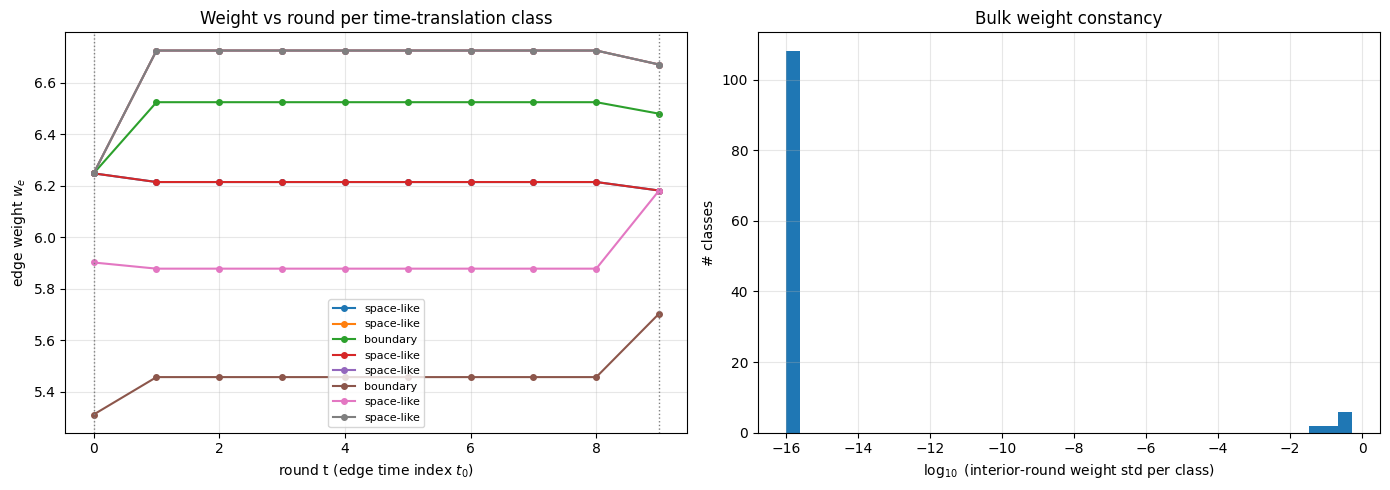

interior-round weight std: max=5.13e-01, median=0.00e+00 | fraction < 1e-9: 91.5%


In [4]:
wclasses = defaultdict(list)   # sig -> [(t0, weight)]
wlabel = {}
for i, uv in enumerate(dec_edges):
    sig, t0 = edge_signature([uv])
    if sig is None:
        continue
    wclasses[sig].append((t0, float(weights[i])))
    wlabel.setdefault(sig, edge_kind(uv))

# pick the classes that span the most rounds (the bulk-spanning families)
top = sorted(wclasses, key=lambda s: len({t for t, _ in wclasses[s]}), reverse=True)[:8]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for s in top:
    pts = sorted(wclasses[s])
    ts = [t for t, _ in pts]; ws = [w for _, w in pts]
    ax[0].plot(ts, ws, "o-", ms=4, label=wlabel[s])
for tb in (T_MIN, T_MAX):
    ax[0].axvline(tb, color="gray", ls=":", lw=1)
ax[0].set_xlabel("round t (edge time index $t_0$)"); ax[0].set_ylabel("edge weight $w_e$")
ax[0].set_title("Weight vs round per time-translation class"); ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

# Bulk constancy: per-class std of weight over INTERIOR rounds (exclude t_min, t_max)
bulk_std = []
for s, pts in wclasses.items():
    inner = [w for t, w in pts if T_MIN < t < T_MAX]
    if len(inner) >= 2:
        bulk_std.append(np.std(inner))
bulk_std = np.array(bulk_std)
ax[1].hist(np.log10(bulk_std + 1e-16), bins=40, color="#1f77b4")
ax[1].set_xlabel("$\\log_{10}$ (interior-round weight std per class)")
ax[1].set_ylabel("# classes"); ax[1].set_title("Bulk weight constancy")
ax[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "translational_symmetry_weights.png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"interior-round weight std: max={bulk_std.max():.2e}, median={np.median(bulk_std):.2e} "
      f"| fraction < 1e-9: {100 * np.mean(bulk_std < 1e-9):.1f}%")

## 2. $-\log$ joint probability vs round

Same analysis for the correlated edge pairs $(\mu,\nu)$ of the line graph: $-\log P(\mu,\nu)$ should be flat across rounds in the bulk.

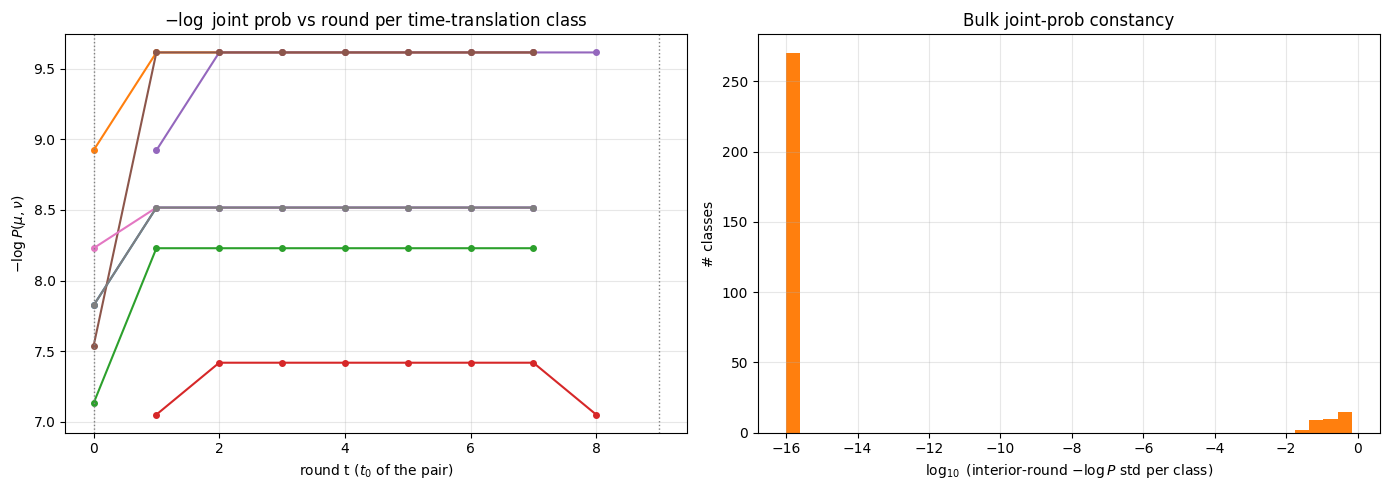

interior-round -logP std: max=6.88e-01, median=0.00e+00 | fraction < 1e-9: 88.2%


In [5]:
jclasses = defaultdict(list)   # sig -> [(t0, -log joint)]
src, dst = line_idx[0], line_idx[1]
for k in range(line_idx.shape[1]):
    if joint[k] <= 0:
        continue
    uv_i, uv_j = dec_edges[src[k]], dec_edges[dst[k]]
    sig, t0 = edge_signature([uv_i, uv_j])
    if sig is None:
        continue
    jclasses[sig].append((t0, float(-np.log(joint[k]))))

topj = sorted(jclasses, key=lambda s: len({t for t, _ in jclasses[s]}), reverse=True)[:8]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for s in topj:
    pts = sorted(jclasses[s])
    ts = [t for t, _ in pts]; vs = [v for _, v in pts]
    ax[0].plot(ts, vs, "o-", ms=4)
for tb in (T_MIN, T_MAX):
    ax[0].axvline(tb, color="gray", ls=":", lw=1)
ax[0].set_xlabel("round t ($t_0$ of the pair)"); ax[0].set_ylabel("$-\\log P(\\mu,\\nu)$")
ax[0].set_title("$-\\log$ joint prob vs round per time-translation class"); ax[0].grid(alpha=0.3)

bulk_std_j = []
for s, pts in jclasses.items():
    inner = [v for t, v in pts if T_MIN < t < T_MAX]
    if len(inner) >= 2:
        bulk_std_j.append(np.std(inner))
bulk_std_j = np.array(bulk_std_j)
ax[1].hist(np.log10(bulk_std_j + 1e-16), bins=40, color="#ff7f0e")
ax[1].set_xlabel("$\\log_{10}$ (interior-round $-\\log P$ std per class)")
ax[1].set_ylabel("# classes"); ax[1].set_title("Bulk joint-prob constancy")
ax[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "translational_symmetry_joint.png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"interior-round -logP std: max={bulk_std_j.max():.2e}, median={np.median(bulk_std_j):.2e} "
      f"| fraction < 1e-9: {100 * np.mean(bulk_std_j < 1e-9):.1f}%")

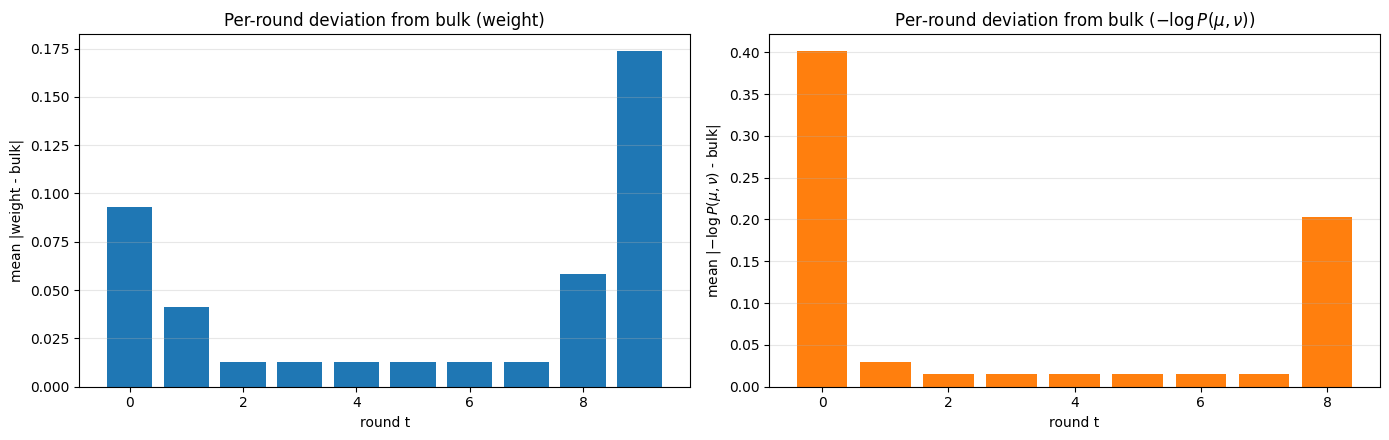

In [6]:
# Boundary vs bulk: how far does each round deviate from the bulk value of its class?
def per_round_deviation(classes):
    dev = defaultdict(list)   # round t -> [|value - class bulk mean|]
    for pts in classes.values():
        inner = [v for t, v in pts if T_MIN < t < T_MAX]
        if len(inner) < 2:
            continue
        mu = np.mean(inner)
        for t, v in pts:
            dev[t].append(abs(v - mu))
    return {t: np.mean(d) for t, d in dev.items()}

dw = per_round_deviation(wclasses); dj = per_round_deviation(jclasses)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for a, d, ttl, cc in ((ax[0], dw, "weight", "#1f77b4"), (ax[1], dj, "$-\\log P(\\mu,\\nu)$", "#ff7f0e")):
    ts = sorted(d); a.bar(ts, [d[t] for t in ts], color=cc)
    a.set_xlabel("round t"); a.set_ylabel(f"mean |{ttl} - bulk|")
    a.set_title(f"Per-round deviation from bulk ({ttl})"); a.grid(alpha=0.3, axis="y")
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "translational_symmetry_boundary.png"), dpi=200, bbox_inches="tight")
plt.show()

## Interpretation

- **Bulk symmetry is essentially exact.** For this config ~90% of weight classes and ~88% of joint-prob classes have interior-round std at numerical zero ($\sim10^{-15}$): within those time-translation classes the weight and $-\log P(\mu,\nu)$ are **identical across rounds** — the bulk decoding graph is exactly time-translation invariant, as expected from the repeating syndrome-extraction round.
- **Boundary breaking extends ~1 round inward.** The remaining ~10% of classes (interior std up to ~0.5) are those whose support touches the first/last rounds. The per-round deviation bars show the symmetry breaking is concentrated at $t=t_{\min},t_{\max}$ and decays within ~1 round — the reset and final-measurement layers (and their immediate neighbours) see a different error-mechanism set. The deep interior ($t_{\min}{+}2 \le t \le t_{\max}{-}2$) is exactly symmetric. (Tighten the bulk window in the std cells to $[t_{\min}{+}2, t_{\max}{-}2]$ to see the tail vanish.)
- **Why it matters.** This invariance means a *single bulk round's* weights/correlations are a sufficient statistic: a decoder (or a learned reweighting model, or the Pearl $\alpha$ calibration) only needs to characterise one bulk round plus the two boundary rounds, rather than every round independently. It also gives a cheap correctness check on any reweighting scheme — bulk reweights must respect the same time-translation symmetry.